### Домашнє завдання: Пониження розмірностей для Аналізу Портретів Клієнтів

#### Контекст
В цьому ДЗ ми попрацюємо з методами пониження розмірності на наборі даних для задачі аналізу портретів клієнтів (Customer Personality Analysis). **В попередньому ДЗ ми працювали з цими даними використовуючи кластеризацію, зараз використаємо кластеризацію і візуалізауємо результати з різними методами.**

Customer Personality Analysis - це аналіз різних сегментів клієнтів компанії. Цей аналіз дозволяє бізнесу краще розуміти своїх клієнтів і полегшує процес адаптації продуктів під конкретні потреби, поведінку та інтереси різних типів клієнтів.

Аналіз портретів клієнтів допомагає бізнесу змінювати свій продукт на основі цільової аудиторії, розділеної на різні сегменти. Наприклад, замість того, щоб витрачати гроші на маркетинг нового продукту для всіх клієнтів у базі даних компанії, бізнес може проаналізувати, який сегмент клієнтів найімовірніше придбає продукт, і потім зосередити маркетингові зусилля лише на цьому сегменті.

#### Вхідні дані
Вам надано набір даних з такими атрибутами:

**Характеристики користувачів:**
- `ID`: Унікальний ідентифікатор клієнта
- `Year_Birth`: Рік народження клієнта
- `Education`: Рівень освіти клієнта
- `Marital_Status`: Сімейний стан клієнта
- `Income`: Річний дохід домогосподарства клієнта
- `Kidhome`: Кількість дітей у домогосподарстві клієнта
- `Teenhome`: Кількість підлітків у домогосподарстві клієнта
- `Dt_Customer`: Дата реєстрації клієнта у компанії
- `Recency`: Кількість днів з моменту останньої покупки клієнта
- `Complain`: 1, якщо клієнт скаржився за останні 2 роки, 0 - якщо ні

**Продукти:**
- `MntWines`: Сума, витрачена на вино за останні 2 роки
- `MntFruits`: Сума, витрачена на фрукти за останні 2 роки
- `MntMeatProducts`: Сума, витрачена на м'ясні продукти за останні 2 роки
- `MntFishProducts`: Сума, витрачена на рибні продукти за останні 2 роки
- `MntSweetProducts`: Сума, витрачена на солодощі за останні 2 роки
- `MntGoldProds`: Сума, витрачена на золото за останні 2 роки

**Акції:**
- `NumDealsPurchases`: Кількість покупок, зроблених з використанням знижок
- `AcceptedCmp1`: 1, якщо клієнт прийняв пропозицію у першій кампанії, 0 - якщо ні
- `AcceptedCmp2`: 1, якщо клієнт прийняв пропозицію у другій кампанії, 0 - якщо ні
- `AcceptedCmp3`: 1, якщо клієнт прийняв пропозицію у третій кампанії, 0 - якщо ні
- `AcceptedCmp4`: 1, якщо клієнт прийняв пропозицію у четвертій кампанії, 0 - якщо ні
- `AcceptedCmp5`: 1, якщо клієнт прийняв пропозицію у п'ятій кампанії, 0 - якщо ні
- `Response`: 1, якщо клієнт прийняв пропозицію в останній кампанії, 0 - якщо ні

**Взаємодія з компанією:**
- `NumWebPurchases`: Кількість покупок, зроблених через вебсайт компанії
- `NumCatalogPurchases`: Кількість покупок, зроблених за каталогом
- `NumStorePurchases`: Кількість покупок, зроблених безпосередньо у магазинах
- `NumWebVisitsMonth`: Кількість відвідувань вебсайту компанії за останній місяць


Для початку, запустіть код нижче. Всі ці кроки ми робили в попередньому ДЗ і для того, щоб результати кластеризації у нас були схожими, потрібно аби передобробка була однаковою.

In [1]:
import pandas as pd

# 1. Завантаження даних
df = pd.read_csv('Clustering Algorithms\data\marketing_campaign.csv', sep='\t')

# 2. Обробка пропущених значень
df['Income_not_filled'] = df.Income.isna()
df.Income = df.Income.fillna(-1)

# 3. Обробка дати реєстрації
df.Dt_Customer = pd.to_datetime(df.Dt_Customer, format='%d-%m-%Y')
today = df.Dt_Customer.max()
df['days_lifetime'] = (today - df.Dt_Customer).dt.days
df['years_customer'] = df.Year_Birth.apply(lambda x: today.year - x)

# 4. Категоризація рівня освіти
df_education = pd.get_dummies(df.Education, prefix='education').astype(int)
df = pd.concat([df, df_education], axis=1)

# 5. Очищення сімейного стану
marital_status_map = {'Alone': 'Single', 'Absurd': 'Else', 'YOLO': 'Else'}
df['Marital_Status_clean'] = df.Marital_Status.map(marital_status_map)
df_ms = pd.get_dummies(df.Marital_Status_clean, prefix='marital').astype(int)
df = pd.concat([df, df_ms], axis=1)

# 6. Форматування доходу і видалення викиду
df.Income = df.Income.astype(int)
df = df[df.Income != 666666]

# 7. Створення фінального набору даних
X = df.drop(['ID', 'Dt_Customer', 'Education', 'Marital_Status', 'Marital_Status_clean'], axis=1)
X.reset_index(drop=True, inplace=True)

### Завдання 1: Виконання кластеризації та пониження розмірності для візуалізації результатів

Ваше завдання — провести кластеризацію клієнтів та візуалізувати результати кластеризації, використовуючи метод головних компонент (PCA) для пониження розмірності даних.

#### Інструкції:

1. **Вибір ключових характеристик:**
   Давайте обмежимось тільки наступними хараткеристиками для кластеризації цього разу:
   - `Income`: Річний дохід домогосподарства клієнта
   - `Recency`: Кількість днів з моменту останньої покупки клієнта
   - `NumStorePurchases`: Кількість покупок, зроблених безпосередньо у магазинах
   - `NumDealsPurchases`: Кількість покупок, зроблених з використанням знижок
   - `days_lifetime`: Кількість днів з моменту реєстрації клієнта у компанії
   - `years_customer`: Вік клієнта
   - `NumWebVisitsMonth`: Кількість відвідувань вебсайту компанії за останній місяць
   
   Відберіть в наборі даних `X` лише ці характеристики.
   
   

2. **Нормалізація даних:**
   Використайте метод `MinMaxScaler` для нормалізації значень обраних характеристик.

3. **Кластеризація:**
   Проведіть кластеризацію клієнтів, використовуючи метод `KMeans` з трьома кластерами.

4. **Пониження розмірності:**
   Використайте метод головних компонент (PCA) для пониження розмірності даних до трьох компонент.

5. **Візуалізація результатів:**
   Використовуючи plolty express побудуйте 3D-графік розподілу клієнтів у просторі трьох головних компонент, де кольором позначено кластери.

6. **Опишіть, що спостерігаєте:**
   Чи кластеризація чітко розділила дані?

Далі ми детальніше проінтерпретуємо результати візуалізації і пониження розмірностей.

In [2]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import plotly.express as px
import numpy as np
%matplotlib inline
from sklearn.manifold import TSNE
from matplotlib.colors import ListedColormap

In [3]:
cols = ['Income', 'Recency', 'NumStorePurchases', 'NumDealsPurchases', 'days_lifetime', 'years_customer', 'NumWebVisitsMonth']
X = df[cols]

In [4]:
sc = StandardScaler()
X_std = sc.fit_transform(X)

In [5]:
kmeans = KMeans(n_clusters=3, n_init='auto')
kmeans.fit(X_std)

labels = kmeans.predict(X_std)
print(labels)

[2 1 0 ... 0 0 2]


C:\Users\Anastasiia\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1436: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(


In [6]:
pca = PCA(n_components=3)
pca.fit(X_std)

PCA(n_components=3)

In [7]:
pca_data = pca.fit_transform(X_std)

In [8]:
df_pca = pd.DataFrame(pca_data, columns=['PCA1', 'PCA2', 'PCA3'])
df_pca['Cluster'] = labels

# Використовуємо plotly для побудови 3D-графіка
fig = px.scatter_3d(df_pca, 
                    x='PCA1', 
                    y='PCA2', 
                    z='PCA3', 
                    color='Cluster', 
                    title='Кластеризація KMeans з 3 компонентами PCA',
                    labels={'PCA1': 'PCA Компонент 1', 'PCA2': 'PCA Компонент 2', 'PCA3': 'PCA Компонент 3'})

# Відображаємо графік
fig.show()

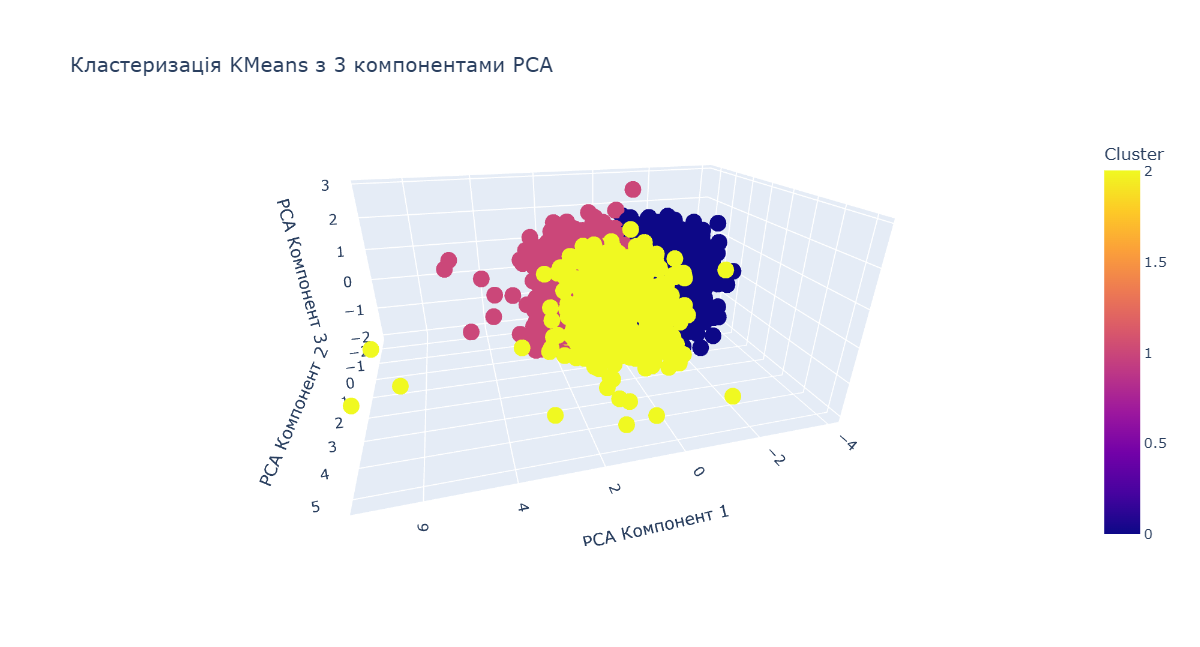

**Спостереження:** Кластеризація KMeans з 3 компонентами PCA чітко розділила дані на три кластери.

### Завдання 2: Аналіз результатів пониження розмірності

1. **Розрахунок частки поясненої дисперсії:**
   Визначте, яка частка загальної варіації даних пояснюється кожною з трьох головних компонент (PC1, PC2, PC3) за допомогою атрибуту `explained_variance_ratio_` об'єкта PCA. Виведіть результат на екран.

2. **Розрахунок кумулятивної частки поясненої дисперсії:**
   Обчисліть кумулятивну частку поясненої дисперсії для трьох головних компонент, щоб зрозуміти, скільки варіації даних пояснюється першими кількома компонентами.

In [9]:
# Частка поясненої дисперсії кожною з головних компонент
explained_variance = pca.explained_variance_ratio_
print("Частка поясненої дисперсії для кожної компоненти:")
for i, variance in enumerate(explained_variance):
    print(f"PC{i+1}: {variance:.4f}")

Частка поясненої дисперсії для кожної компоненти:
PC1: 0.3185
PC2: 0.1966
PC3: 0.1434


In [10]:
# Кумулятивна частка поясненої дисперсії
cumulative_variance = explained_variance.cumsum()
print("Кумулятивна частка поясненої дисперсії:")
for i, cumulative in enumerate(cumulative_variance):
    print(f"До PC{i+1}: {cumulative:.4f}")

Кумулятивна частка поясненої дисперсії:
До PC1: 0.3185
До PC2: 0.5151
До PC3: 0.6585


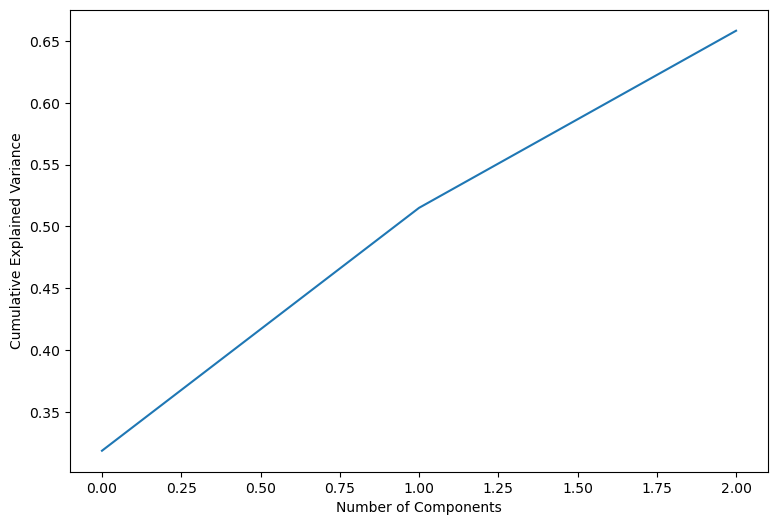

In [11]:
plt.figure(figsize=(9, 6))
plt.plot(cumulative_variance)
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance');

### Завдання 3: Інтерпретація "Loadings"

Продовжуємо інтерпретацію результатів `PCA`і познайомимось з новим поняттям `loadings`, яке допоможе нам знайти звʼязок між головними компонентами і оригінальними ознаками в наборі даних.

Ми зараз побудували візуалізацію кластерів точок даних в просторі трьох головних компонент. Але хочеться знайти звʼязок між головними компонентами і оригінальними ознаками. Для розуміння, які початкові характеристики даних мають найбільший вплив на ці головні компоненти, ми можемо використати атрибут `components_` методу `PCA`.

#### Що таке `pca.components_`?

`pca.components_` — це масив, який містить коефіцієнти (або "ваги"), що показують внесок кожної вихідної ознаки у кожну з головних компонент. Ці коефіцієнти ще називаються **"loading"** або "навантаженнями" компонент.

- **Loadings** (`навантаження`) відображають важливість кожної змінної (ознаки) для відповідної головної компоненти. Вони показують, яким чином змінні поєднуються, щоб утворити нові, зменшені вимірювання.
- Якщо коефіцієнт має високе абсолютне значення (як позитивне, так і негативне), це вказує на те, що відповідна змінна сильно впливає на головну компоненту.

#### Саме завдання
Ваше завдання — обчислити "навантаження" для кожної з головних компонент і інтерпретувати результати.

1. **Обчислення loadings для компонент:**
   Використайте атрибут `components_` об'єкта PCA для створення DataFrame, який відображатиме внесок кожної вихідної ознаки в кожну головну компоненту.

2. **Інтерпретація результатів:**
   Виведіть значення "навантажень" і проаналізуйте, які ознаки найбільше впливають на кожну головну компоненту.

In [12]:
pca_loadings = pd.DataFrame(pca.components_, columns=cols)

In [13]:
pca_loadings

,Income,Recency,NumStorePurchases,NumDealsPurchases,days_lifetime,years_customer,NumWebVisitsMonth
0,-0.584238,-0.010075,-0.488621,0.198661,0.132683,-0.189393,0.571728
1,0.165255,0.036810,0.384659,0.608119,0.602585,0.208946,0.216329
2,-0.044491,0.975799,-0.080566,-0.034808,-0.022223,0.193368,-0.015815


In [14]:
# Для кожного компоненту знайду ознаку з найбільшим абсолютним значенням
most_influential_features = pca_loadings.abs().idxmax(axis=1)

for i, feature in enumerate(most_influential_features):
    print(f"Найвпливовіша ознака для компоненти {i+1}: {feature}")

Найвпливовіша ознака для компоненти 1: Income
Найвпливовіша ознака для компоненти 2: NumDealsPurchases
Найвпливовіша ознака для компоненти 3: Recency


**Спостереження:** 
- Для `компоненти 1` найвпливовішою ознакою є `Income`
- Для `компоненти 2` найвпливовішою ознакою є `NumDealsPurchases`
- Для `компоненти 3` найвпливовішою ознакою є `Recency`

### Завдання 4

Давайте проаналізуємо "навантаження" (**loadings**) для трьох головних компонент після вилучення ознаки `Income`. Це допоможе нам зрозуміти, як змінилася важливість інших ознак для кожної головної компоненти, коли одна з ключових характеристик (`Income`) була вилучена.

#### Кроки для проведення аналізу і ваше завдання:

1. Видаліть ознаку `Income` з нашого набору даних `X` і повторно виконайте PCA (метод головних компонент) для отримання нових "навантажень".

2. Обчисліть нові "навантаження" для трьох головних компонент на наборі даних без `Income`

3. Проаналізуйте, які ознаки мають найбільший вплив на кожну головну компоненту після вилучення `Income`.

4. Перегляньте, наскільки кожна з головних компонент пояснює дисперсію в даних без ознаки `Income`.

In [15]:
X_without_income = X.drop(['Income'], axis=1)

In [16]:
X_without_income_std = sc.fit_transform(X_without_income)

In [17]:
kmeans = KMeans(n_clusters=3, n_init='auto')
kmeans.fit(X_without_income_std)

labels_without_income = kmeans.predict(X_without_income_std)

C:\Users\Anastasiia\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1436: UserWarning:

KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.



In [18]:
pca.fit(X_without_income_std)

pca_data = pca.fit_transform(X_without_income_std)

In [36]:
df_pca = pd.DataFrame(pca_data, columns=['PCA1', 'PCA2', 'PCA3'])
df_pca['Cluster'] = labels_without_income

# Використовуємо plotly для побудови 3D-графіка
fig = px.scatter_3d(df_pca, 
                    x='PCA1', 
                    y='PCA2', 
                    z='PCA3', 
                    color='Cluster', 
                    title='Кластеризація KMeans з 3 компонентами PCA',
                    labels={'PCA1': 'PCA Компонента 1', 'PCA2': 'PCA Компонента 2', 'PCA3': 'PCA Компонента 3'})

# Відображаємо графік
fig.show()

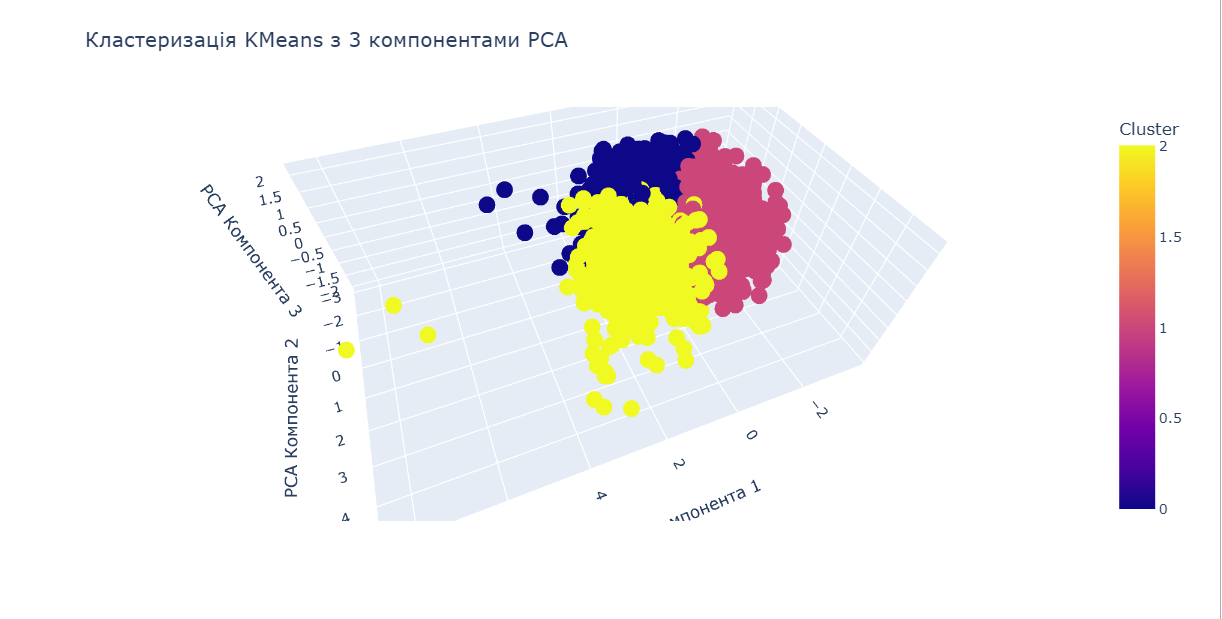

In [20]:
# Частка поясненої дисперсії кожною з головних компонент
explained_variance = pca.explained_variance_ratio_
print("Частка поясненої дисперсії для кожної компоненти:")
for i, variance in enumerate(explained_variance):
    print(f"PC{i+1}: {variance:.4f}")

Частка поясненої дисперсії для кожної компоненти:
PC1: 0.2739
PC2: 0.2144
PC3: 0.1668


In [21]:
# Кумулятивна частка поясненої дисперсії
cumulative_variance = explained_variance.cumsum()
print("Кумулятивна частка поясненої дисперсії:")
for i, cumulative in enumerate(cumulative_variance):
    print(f"До PC{i+1}: {cumulative:.4f}")

Кумулятивна частка поясненої дисперсії:
До PC1: 0.2739
До PC2: 0.4884
До PC3: 0.6552


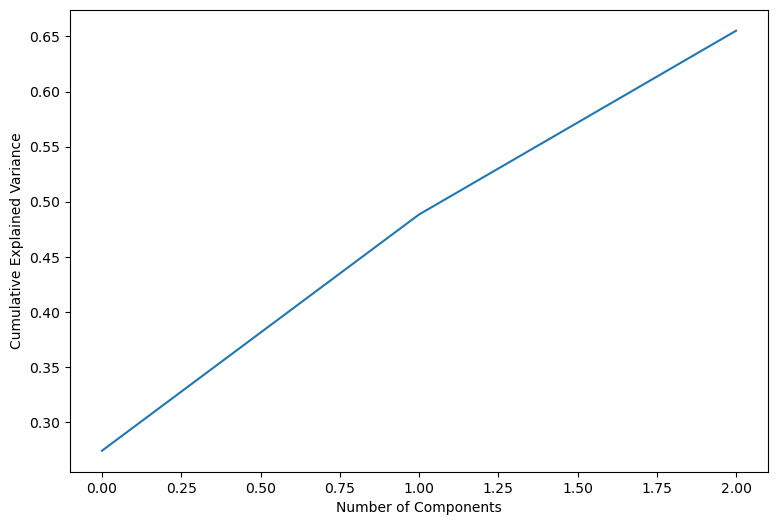

In [22]:
plt.figure(figsize=(9, 6))
plt.plot(cumulative_variance)
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance');

In [23]:
pca_loadings = pd.DataFrame(pca.components_, columns=cols[1:])

In [24]:
# Для кожного компоненту знайду ознаку з найбільшим абсолютним значенням
most_influential_features = pca_loadings.abs().idxmax(axis=1)

for i, feature in enumerate(most_influential_features):
    print(f"Найвпливовіша ознака для компоненти {i+1}: {feature}")

Найвпливовіша ознака для компоненти 1: NumWebVisitsMonth
Найвпливовіша ознака для компоненти 2: NumStorePurchases
Найвпливовіша ознака для компоненти 3: Recency


**Спостереження:** 
- Для `компоненти 1` найвпливовішою ознакою до вилучення `Income` була саме `Income`, а після вилучення - `NumWebVisitsMonth`
- Для `компоненти 2` найвпливовішою ознакою до вилучення `Income` була `NumDealsPurchases`, а після вилучення - `NumStorePurchases`
- Для `компоненти 3` найвпливовішою ознакою до вилучення `Income` була і є `Recency`

Частка поясненої дисперсії для кожної компоненти змінилась:
- PC1: було `0.3185`, стало `0.2739` (частка зменшилась)
- PC2: було `0.1966`, стало `0.2144` (частка збільшилась)
- PC3: було `0.1434`, стало `0.1668` (частка збільшилась)

Здається ніби частки поясненої дисперсії більш рівномірно розподілені після видалення ознаки `Income`.

### Завдання 5: Візуалізація кластеризації за допомогою t-SNE

Ваше завдання — використати метод t-SNE для візуалізації результатів кластеризації клієнтів у двовимірному просторі. Метод t-SNE допомагає знизити розмірність даних та зберегти локальні структури в даних, що робить його ефективним для візуалізації високорозмірних даних. Ми також зможемо порівняти результат цього методу з РСА.

1. Використайте метод t-SNE для зниження розмірності до 2х вимірів даних, які включають ознаки всі, що і в завданні 1, а також були відмасштабовані перед пониженням розмірностей.

2. Створіть новий DataFrame з координатами, отриманими після застосування t-SNE, та додайте до нього мітки кластерів.

3. Побудуйте інтерактивний 2D-графік розподілу клієнтів, де кольором буде позначено різні кластери і проаналізуйте графік з рекомендаціями нижче (можливо треба буде вивести додаткові візуалізації чи таблиці для інтерпретації, але треба прям зрозуміти, які ознаки формують який кластер і чим кластери відрізняються одне від одного).

  **Опишіть отримані кластери з точки зору ознак.**

4. Опишіть відмінність графіка tSNE від PCA.

#### ЯК можна інтерпретувати з t-SNE?

Хоча t-SNE не надає "компонентів" як РСА, він забезпечує низьковимірне представлення даних, яке можна візуально інтерпретувати:

- **Кластери:** t-SNE особливо добре показує кластери подібних точок. Якщо ви бачите чітко визначені кластери на графіку t-SNE, це свідчить про наявність груп схожих спостережень у ваших даних. Проаналізувати їх можемо, якщо додамо дані в `hover_data` або якщо якісь з даних виведемо як розмір чи форма точок на візуалізації. Також корисно може бути вивести середні значення ознак по кластерам.
- **Локальна структура:** Відносне розташування точок одного кластеру на графіку t-SNE може допомогти вам зрозуміти, які дані подібні між собою.
- **Глобальна структура:** Будьте обережні; t-SNE менш надійний для відображення глобальних структур (наприклад, відстаней між кластерами) у порівнянні з PCA, бо t-SNE націлений на збереження саме локальних структур.

In [25]:
tsne = TSNE(n_components=2, random_state=0)
tsne_data = tsne.fit_transform(X_std)

In [26]:
# Створення DataFrame з координатами t-SNE
tsne_df = pd.DataFrame(tsne_data, columns=['TSNE1', 'TSNE2'])

# Додаю мітки кластерів
tsne_df['Cluster'] = labels

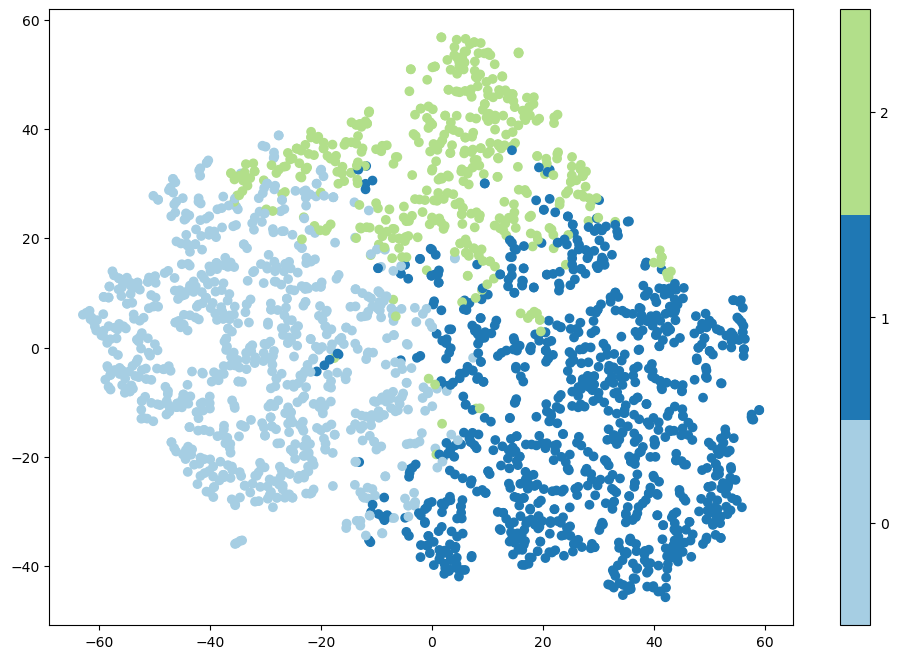

In [27]:
cmap = ListedColormap(plt.cm.Paired.colors[:3])

plt.figure(figsize=(12, 8))
plt.scatter(tsne_df.iloc[:, 0], tsne_df.iloc[:, 1], c=labels, cmap=cmap)
plt.colorbar(ticks=range(3))
plt.clim(-0.5, 2.5)
plt.show()

In [28]:
fig = px.scatter(
    tsne_df, 
    x='TSNE1', 
    y='TSNE2', 
    color='Cluster', 
    title='t-SNE Візуалізація', 
    labels={'TSNE1': 't-SNE 1', 'TSNE2': 't-SNE 2'}
)

fig.show()

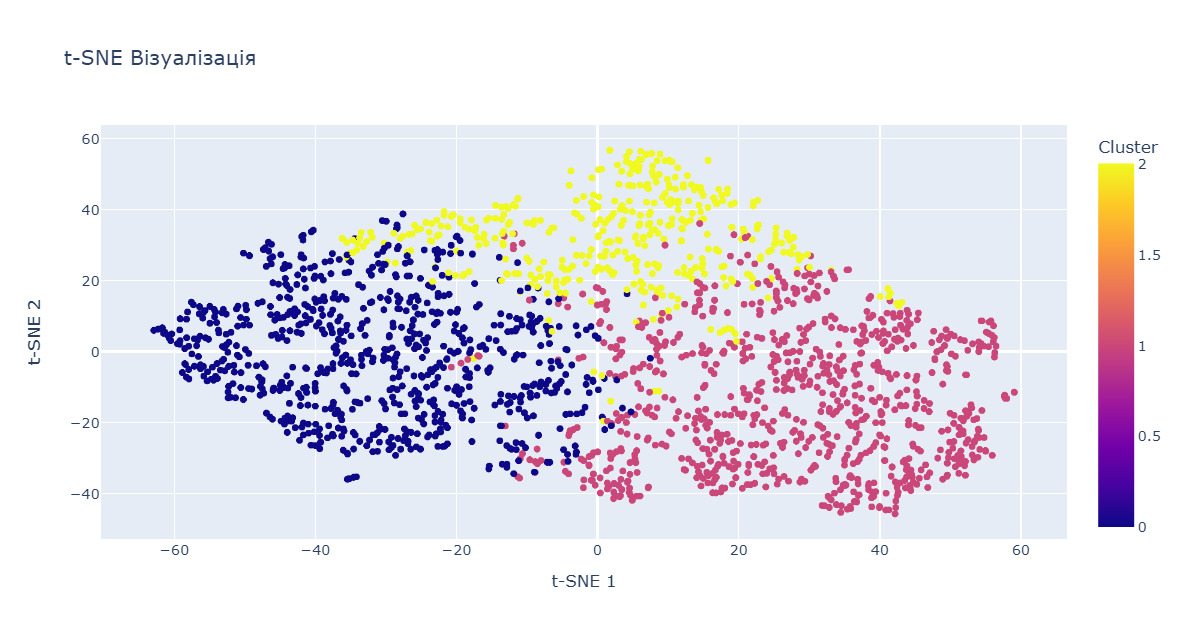

In [29]:
# Створення DataFrame з X_std
X_std_df = pd.DataFrame(X_std, columns=cols)

# Додавання необхіднтх ознак до tsne_df
tsne_df['Income'] = X_std_df['Income']
tsne_df['Recency'] = X_std_df['Recency']
tsne_df['NumStorePurchases'] = X_std_df['NumStorePurchases']
tsne_df['NumDealsPurchases'] = X_std_df['NumDealsPurchases']
tsne_df['days_lifetime'] = X_std_df['days_lifetime']
tsne_df['years_customer'] = X_std_df['years_customer']

# Побудова інтерактивного графіку
fig = px.scatter(
    tsne_df, 
    x='TSNE1', 
    y='TSNE2', 
    color='Cluster', 
    title='t-SNE Візуалізація',
    hover_data=['Income', 'Recency', 'NumStorePurchases', 'NumDealsPurchases', 'days_lifetime', 'years_customer'],
    labels={'TSNE1': 't-SNE 1', 'TSNE2': 't-SNE 2'}
)

fig.show()

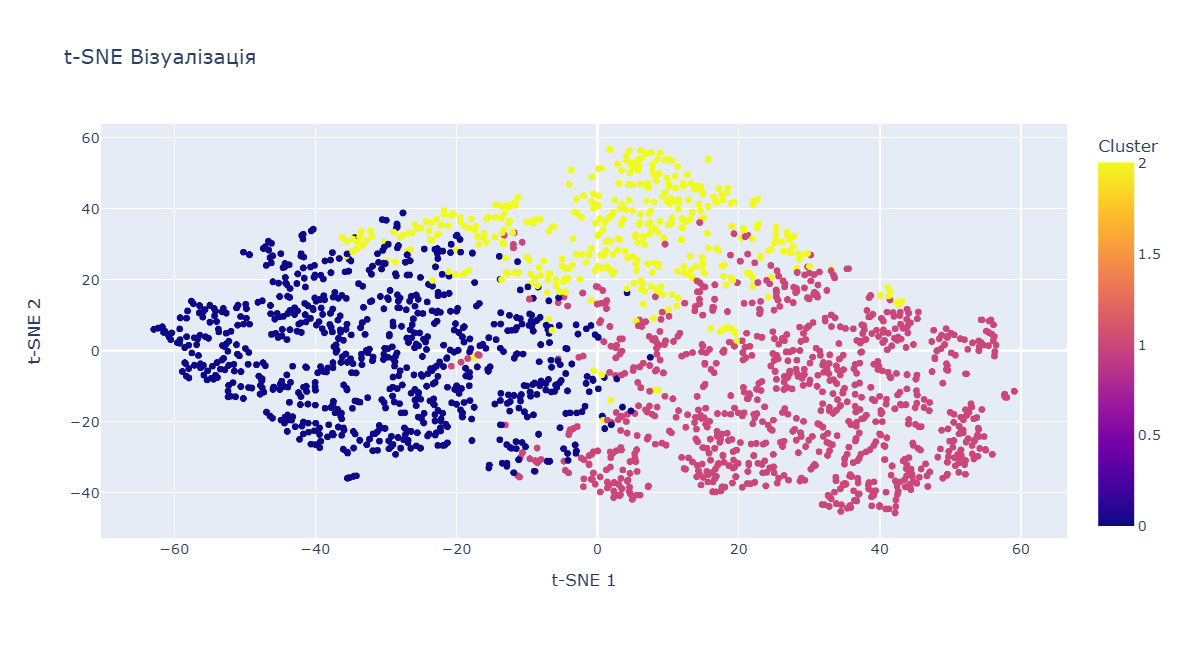

In [30]:
# Розрахунок середніх значень ознак по кожному кластеру
cluster_means = tsne_df.groupby('Cluster').mean()

pd.DataFrame(cluster_means)

,TSNE1,TSNE2,Income,Recency,NumStorePurchases,NumDealsPurchases,days_lifetime,years_customer
Cluster,,,,,,,,
0,-31.000420,-0.983885,0.958037,0.007737,0.784516,-0.456525,-0.189551,0.179395
1,27.020376,-12.789784,-0.830971,-0.022308,-0.804101,-0.264154,-0.204322,-0.272856
2,2.732251,32.183773,0.024075,0.033244,0.281694,1.387305,0.776561,0.252964


In [34]:
# Нормалізуємо від'ємні Income значення або додаємо константу, щоб зробити всі значення додатніми
if tsne_df['Income'].min() < 0:
    tsne_df['Income_scaled'] = tsne_df['Income'] - tsne_df['Income'].min() + 1
else:
    tsne_df['Income_scaled'] = tsne_df['Income']

# Побудова інтерактивного графіка з Income_scaled для зміни розміру точок
fig = px.scatter(
    tsne_df, 
    x='TSNE1', 
    y='TSNE2', 
    color='Cluster', 
    size='Income_scaled',  # Використовуємо нормалізований дохід для розміру
    size_max=15,  # Обмежуємо максимальний розмір точок
    title='Візуалізація t-SNE з доходом як розміром точки',
    hover_data=['Income', 'Recency', 'NumStorePurchases', 'NumDealsPurchases', 'days_lifetime', 'years_customer'],
    labels={'TSNE1': 't-SNE 1', 'TSNE2': 't-SNE 2'}
)

fig.show()

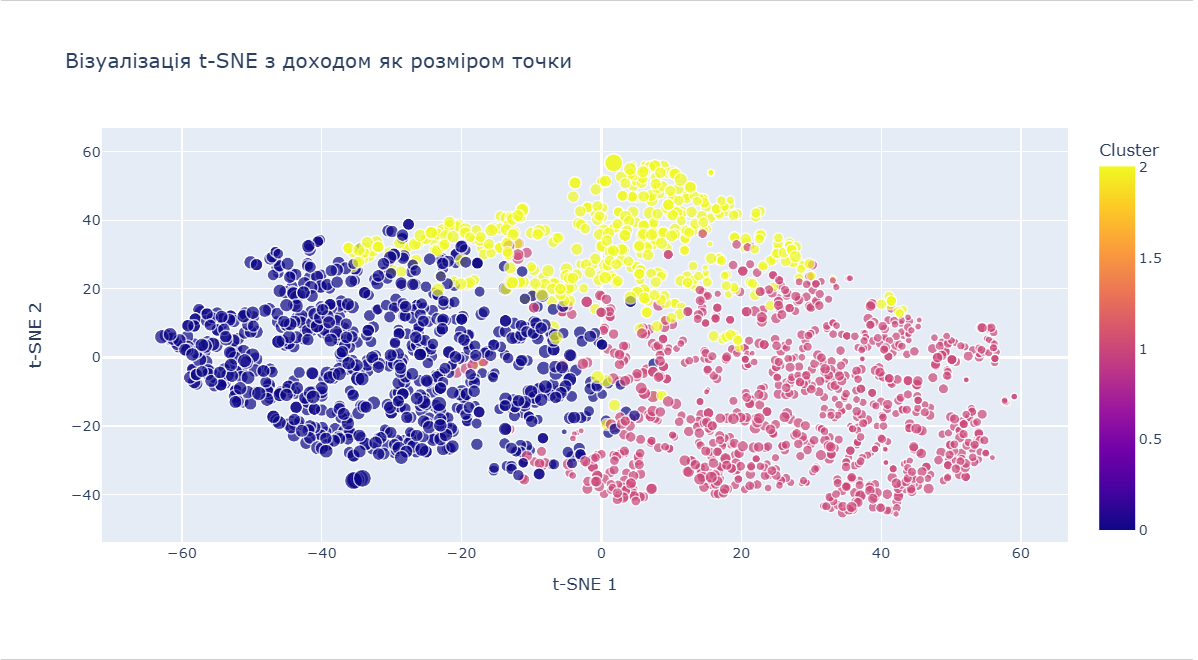

In [32]:
# Нормалізуємо від'ємні значення або додаємо константу
if tsne_df['NumStorePurchases'].min() < 0:
    tsne_df['NumStorePurchases_scaled'] = tsne_df['NumStorePurchases'] - tsne_df['NumStorePurchases'].min() + 1
else:
    tsne_df['NumStorePurchases_scaled'] = tsne_df['NumStorePurchases']

In [35]:
fig = px.scatter(
    tsne_df, 
    x='TSNE1', 
    y='TSNE2', 
    color='Cluster', 
    size='NumStorePurchases_scaled',  # Використовуємо нормалізовані значення
    size_max=15,  # Обмежуємо максимальний розмір точок
    title='Візуалізація t-SNE з NumStorePurchases як розміром точки',
    hover_data=['Income', 'Recency', 'NumStorePurchases', 'NumDealsPurchases', 'days_lifetime', 'years_customer'],
    labels={'TSNE1': 't-SNE 1', 'TSNE2': 't-SNE 2'}
)

fig.show()

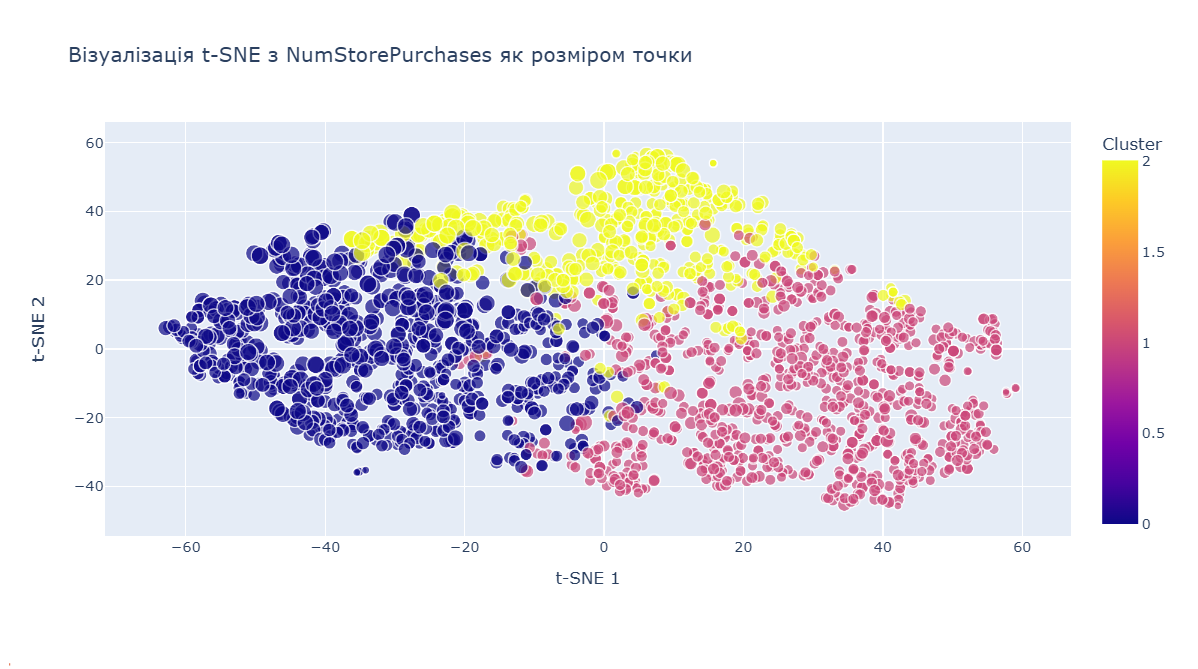

### **Висновок:** 
##### PCA (Principal Component Analysis): 
- Кластеризація `KMeans з 3 компонентами PCA` досить чітко розділила дані на три кластери. Це свідчить про те, що ці три компоненти містять достатньо інформації для вдалої кластеризації даних. 
- Також на графіку можна спостерігати викиди і кластерах `0` та `2`. Це може вказувати на аномальні дані або окремі групи клієнтів, які сильно відрізняються від інших. 

##### t-SNE (t-distributed Stochastic Neighbor Embedding): 
- Я бачу чітко визначені кластери на графіку `t-SNE`, це свідчить про наявність груп схожих спостережень у даних. 
- Аналіз середніх значень ознак показує, що до кластеру `0` потрапили дані, для яких компонента `TSNE1` має велике негативне значення, до кластеру `1` потрапили дані, для яких компонента `TSNE1` має велике позитивне значення, до кластеру `2` потрапили дані, для яких компонента `TSNE1` має значення близьке до `2.7`. Також добре видно вплив ознак `NumStorePurchases` та `Income`. До кластеру `0` потрапили дані, для яких компоненти `NumStorePurchases` та `Income` мають велике позитивне значення, до кластеру `1` потрапили дані, для яких компонентм `NumStorePurchases` та `Income` мають велике негативне значення, до кластеру `2` потрапили дані, для яких компонента `NumStorePurchases` має значення близьке до `0.28`, а компонента `Income` має значення близьке до `0.02`. 
- Це ткож добре видно на візуалізаціях з розміром точок, що залежить від даних ознак, а саме `Візуалізація t-SNE з NumStorePurchases як розміром точки` та `Візуалізація t-SNE з доходом як розміром точки`.


##### **Відмінності між графіками PCA та t-SNE**:

PCA (Principal Component Analysis):
- PCA лінійно проектує багатовимірні дані на простір з меншою кількістю вимірів.
- Основна мета PCA — зменшення вимірності, зберігаючи глобальні відносини між усіма точками. Тому на графіку PCA кластери можуть бути менш чітко розділені. 
- PCA добре підходить для спрощення даних та аналізу їх загальної структури, проте він менш ефективний у збереженні локальної структури, особливо для нелінійних залежностей.
- PCA може використовувати більше компонентів, ніж 2 або 3, оскільки кожна компонента представляє напрямок найбільшої дисперсії у даних.

t-SNE (t-distributed Stochastic Neighbor Embedding):
- Основна мета t-SNE — збереження локальної структури даних. Тому точки, які подібні між собою, будуть близько одна до одної.
- t-SNE добре підходить для візуалізації високовимірних даних у 2D чи 3D просторі.
- На графіку t-SNE чіткіше видно розділення кластерів. 
- t-SNE зазвичай використовується для проекції на 2D або 3D.

##### **Підсумок:**
- t-SNE надає чіткіше розділення кластерів, але може втрачати глобальну картину.
- PCA зберігає загальну структуру даних, але може не так чітко показувати локальні кластери.